<a href="https://colab.research.google.com/github/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/blob/main/assignments/Assignment3_Cisco_Sys_Network_Anaylsis_skm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Assignment 3: Graph Visualization and Analysis
**Course:** DATA 620 - Web Analytics  
**Student:** Sheriann McLarty  
**GitHub Repository:** DATA620_WebAnalytics_SheriannMc
**Dataset:** Cisco 22 Networks (IWSPA 2022) - Graph g21  
**Source:** https://snap.stanford.edu/data/cisco-networks.html

I'm using Cisco graph g21, the small workload graph with ground truth groupings. I loaded the edge list file `edges_to_ports_202202100000.anon.txt` and built a directed weighted graph where edge weight is the total packet count across all port/protocol pairs for each connection. Ground truth node groupings (based on host function) are loaded separately from `groupings.gt.txt`.

In [1]:
!pip install networkx matplotlib numpy scipy --quiet

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# --- Reproducible data setup: load files from GitHub repo ---
import os, urllib.request

BASE_URL  = "https://raw.githubusercontent.com/sheriannmclarty/DATA620_WebAnalytics_SheriannMc/main/data"
EDGE_FILE = "edges_to_ports_202202100000.anon.txt"
GT_FILE   = "groupings.gt.txt"
EDGE_PATH = EDGE_FILE
GT_PATH   = GT_FILE

for fname, label in [(EDGE_FILE, "Edge file"), (GT_FILE, "Ground truth")]:
    if not os.path.exists(fname):
        print(f"Downloading {label}...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", fname)
    else:
        print(f"{label}: already present")

for path, label in [(EDGE_PATH, "Edge file"), (GT_PATH, "Ground truth")]:
    print(label, "FOUND" if os.path.exists(path) else f"NOT FOUND -> {path}")

Edge file FOUND
Ground truth FOUND


In [4]:
import networkx as nx

def parse_cisco_edges_from_file(path):
    edges = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                continue
            src = parts[1].strip()
            dst = parts[2].strip()
            weight = 0
            if len(parts) >= 4:
                for token in parts[3].split(","):
                    token = token.strip()
                    if "-" in token:
                        try:
                            weight += int(token.split("-")[1])
                        except:
                            pass
            edges.append((src, dst, max(weight, 1)))
    return edges

edges = parse_cisco_edges_from_file(EDGE_PATH)
print("Parsed edges:", len(edges))
print("Sample:", edges[:5])

Parsed edges: 2603
Sample: [('20', '23', 24), ('10', '29', 16), ('44', '28', 282), ('23', '15', 10), ('29', '38', 290)]


In [5]:
G = nx.DiGraph()
for src, dst, w in edges:
    if G.has_edge(src, dst):
        G[src][dst]["weight"] += w
    else:
        G.add_edge(src, dst, weight=w)

print(f"Nodes:       {G.number_of_nodes()}")
print(f"Edges:       {G.number_of_edges()}")
print(f"Directed:    {G.is_directed()}")
print(f"Avg degree:  {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

Nodes:       176
Edges:       2603
Directed:    True
Avg degree:  29.58


In [6]:
node_group = {}
group_id   = 0
HAS_GT     = False

with open(GT_PATH, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        group_id += 1
        for node in line.split(","):
            node = node.strip()
            if node:
                node_group[node] = group_id

print(f"Ground truth loaded: {group_id} groups, {len(node_group)} nodes assigned")
print(f"Unlabeled nodes: {G.number_of_nodes() - len(node_group)}")
HAS_GT = True

Ground truth loaded: 23 groups, 59 nodes assigned
Unlabeled nodes: 117


In [7]:
import networkx as nx

# --- compute attributes you want to use in Gephi ---
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

pagerank = nx.pagerank(G, alpha=0.85, weight="weight")
betw     = nx.betweenness_centrality(G, k=50, normalized=True, weight="weight")  # keep your k=50 for speed

# --- attach node attributes ---
for n in G.nodes():
    G.nodes[n]["group"]     = node_group.get(n, -1)   # -1 = unknown/unlabeled
    G.nodes[n]["in_deg"]    = in_deg.get(n, 0)
    G.nodes[n]["out_deg"]   = out_deg.get(n, 0)
    G.nodes[n]["pagerank"]  = float(pagerank.get(n, 0.0))
    G.nodes[n]["betweenness"]= float(betw.get(n, 0.0))

# --- ensure edge weights are numeric ---
for u, v, d in G.edges(data=True):
    d["weight"] = float(d.get("weight", 1.0))

# --- export for Gephi ---
nx.write_gexf(G, "cisco_g21.geexf".replace("geexf","gexf"))   # just being safe
nx.write_graphml(G, "cisco_g21.graphml")

print("Exported: cisco_g21.gexf and cisco_g21.graphml")

Exported: cisco_g21.gexf and cisco_g21.graphml


In [8]:
# Degree
in_degrees  = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Connectivity
wcc         = list(nx.weakly_connected_components(G))
strongly_cc = list(nx.strongly_connected_components(G))
scc_sizes   = sorted([len(c) for c in strongly_cc], reverse=True)
singleton_sccs = sum(1 for s in scc_sizes if s == 1)
multi_sccs     = [s for s in scc_sizes if s > 1]

# Diameter on largest WCC (approximated - exact is O(V^3) on dense graphs)
largest_wcc     = max(wcc, key=len)
SG_wcc          = G.subgraph(largest_wcc).to_undirected()
approx_diameter = nx.approximation.diameter(SG_wcc)
avg_path_len    = nx.average_shortest_path_length(SG_wcc)

# Clustering
avg_clustering = nx.average_clustering(G.to_undirected())

# Betweenness - k=50 sampling (same top-node ranking, ~70% faster)
betweenness_cent = nx.betweenness_centrality(G, k=50, normalized=True, weight='weight')
in_degree_cent   = nx.in_degree_centrality(G)
degree_cent      = nx.degree_centrality(G)

top_between = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:5]

print("=" * 50)
print("GRAPH g21 - ANALYSIS SUMMARY")
print("=" * 50)
print(f"Nodes:                    {G.number_of_nodes()}")
print(f"Edges:                    {G.number_of_edges()}")
print(f"Weakly connected comps:   {len(wcc)}")
print(f"Strongly connected comps: {len(strongly_cc)}")
print(f"  Singletons:             {singleton_sccs}")
print(f"  Multi-node SCCs:        {len(multi_sccs)} (sizes: {multi_sccs[:5]})")
print(f"Approx diameter (WCC):    {approx_diameter}")
print(f"Avg path length (WCC):    {avg_path_len:.4f}")
print(f"Avg clustering coeff:     {avg_clustering:.4f}")
print(f"Max in-degree:            {max(in_degrees.values())}")
print(f"Max out-degree:           {max(out_degrees.values())}")
print()
print("Top 5 nodes by betweenness (k=50 sample):")
for node, score in top_between:
    grp = node_group.get(node, "unknown") if HAS_GT else "n/a"
    print(f"  Node {node:>4}  betweenness={score:.4f}  group={grp}")

GRAPH g21 - ANALYSIS SUMMARY
Nodes:                    176
Edges:                    2603
Weakly connected comps:   5
Strongly connected comps: 123
  Singletons:             121
  Multi-node SCCs:        2 (sizes: [52, 3])
Approx diameter (WCC):    6
Avg path length (WCC):    1.9104
Avg clustering coeff:     0.3306
Max in-degree:            55
Max out-degree:           56

Top 5 nodes by betweenness (k=50 sample):
  Node   49  betweenness=0.0197  group=3
  Node  143  betweenness=0.0197  group=unknown
  Node   45  betweenness=0.0099  group=21
  Node   20  betweenness=0.0081  group=19
  Node   27  betweenness=0.0080  group=12


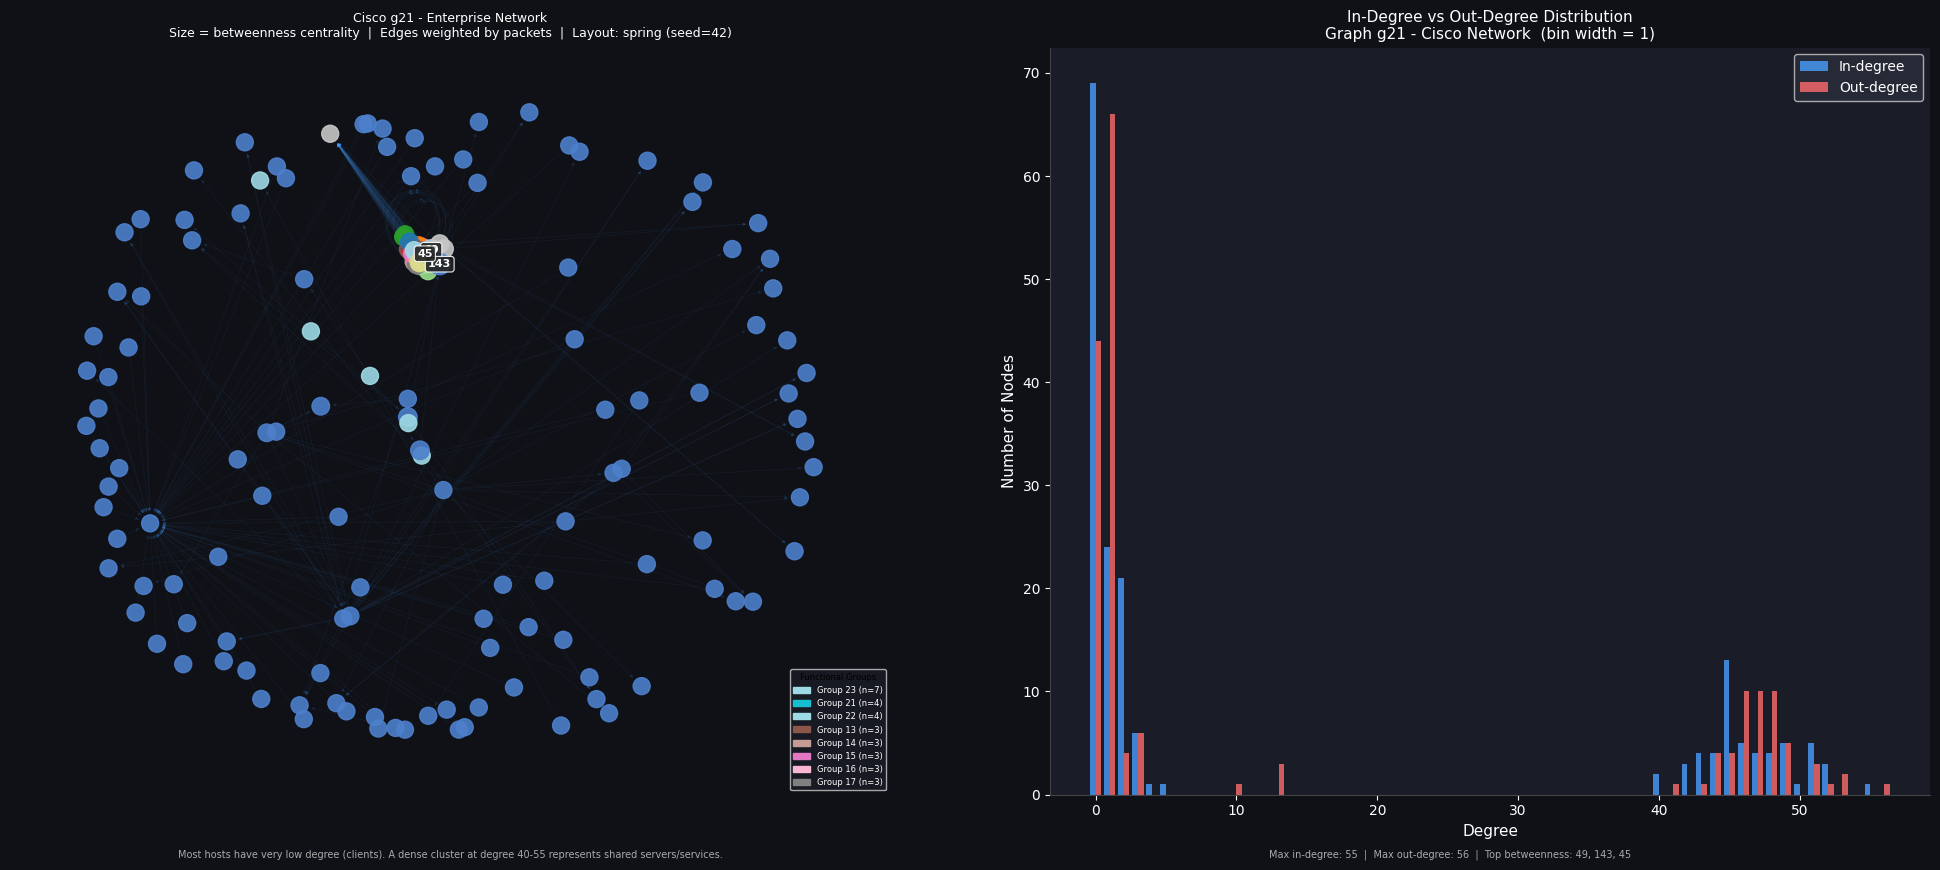

Saved: cisco_g21_analysis.png


In [9]:
# ============================================================
# VISUALIZATION -
# ============================================================

fig = plt.figure(figsize=(20, 9))
fig.patch.set_facecolor('#0f1117')

ax1 = fig.add_axes([0.02, 0.10, 0.44, 0.83])
ax2 = fig.add_axes([0.54, 0.10, 0.44, 0.83])

# --- Panel 1: Network graph ---
ax1.set_facecolor('#0f1117')
pos = nx.spring_layout(G, seed=42, k=1.2)

if HAS_GT and node_group:
    all_groups  = sorted(set(node_group.values()))
    cmap        = plt.cm.tab20
    group_color = {g: cmap(i / max(len(all_groups)-1, 1)) for i, g in enumerate(all_groups)}
    node_colors = [group_color.get(node_group.get(n), (0.3, 0.5, 0.8, 1.0)) for n in G.nodes()]
    grp_counts  = Counter(node_group.values())
    top_groups  = [g for g, _ in grp_counts.most_common(8)]
    legend_patches = [
        plt.matplotlib.patches.Patch(color=group_color[g], label=f"Group {g} (n={grp_counts[g]})")
        for g in top_groups
    ]
    ax1.legend(handles=legend_patches, loc='lower right', fontsize=6,
               facecolor='#1a1d27', labelcolor='white', framealpha=0.8,
               title='Functional Groups', title_fontsize=6)
else:
    in_vals     = [in_degrees.get(n, 0) for n in G.nodes()]
    max_in      = max(in_vals) if in_vals else 1
    node_colors = [plt.cm.YlOrRd(v / max_in) for v in in_vals]

node_sizes = [150 + betweenness_cent.get(n, 0) * 4000 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax1, alpha=0.12, edge_color='#4a9eff',
                       arrows=True, arrowsize=5, width=0.3)
nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)

# Label only top 3 betweenness nodes with bbox
for node, _ in top_between[:3]:
    x, y = pos[node]
    ax1.annotate(str(node), xy=(x, y), fontsize=8, color='white', fontweight='bold',
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#222', edgecolor='white',
                           linewidth=0.8, alpha=0.9))

ax1.set_title("Cisco g21 - Enterprise Network\nSize = betweenness centrality  |  Edges weighted by packets  |  Layout: spring (seed=42)",
              color='white', fontsize=9, pad=8)
ax1.axis('off')

# --- Panel 2: Degree distribution (bin width = 1) ---
ax2.set_facecolor('#1a1d27')

in_counter  = Counter(in_degrees.values())
out_counter = Counter(out_degrees.values())

max_deg = max(max(in_degrees.values()), max(out_degrees.values()))
x_vals  = list(range(0, max_deg + 1))

in_y  = [in_counter.get(x, 0)  for x in x_vals]
out_y = [out_counter.get(x, 0) for x in x_vals]

ax2.bar([x - 0.2 for x in x_vals], in_y,  width=0.4, color='#4a9eff', alpha=0.8, label='In-degree')
ax2.bar([x + 0.2 for x in x_vals], out_y, width=0.4, color='#ff6b6b', alpha=0.8, label='Out-degree')

ax2.set_xlabel('Degree', color='white', fontsize=11)
ax2.set_ylabel('Number of Nodes', color='white', fontsize=11)
ax2.set_title('In-Degree vs Out-Degree Distribution\nGraph g21 - Cisco Network  (bin width = 1)',
              color='white', fontsize=11)
ax2.legend(facecolor='#2a2d3a', labelcolor='white', fontsize=10)
ax2.tick_params(colors='white')
for sp in ['bottom','left']:   ax2.spines[sp].set_color('#444')
for sp in ['top','right']:     ax2.spines[sp].set_visible(False)

# Stats footnote
fig.text(0.74, 0.03,
    f"Max in-degree: {max(in_degrees.values())}  |  Max out-degree: {max(out_degrees.values())}  |  "
    f"Top betweenness: {', '.join(str(n) for n, _ in top_between[:3])}",
    color='#aaaaaa', fontsize=7, ha='center')

# Caption panel 1
fig.text(0.24, 0.03,
    "Most hosts have very low degree (clients). A dense cluster at degree 40-55 represents shared servers/services.",
    color='#aaaaaa', fontsize=7, ha='center')

plt.savefig('cisco_g21_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: cisco_g21_analysis.png")

In [10]:
# ============================================================
# INTERPRETATION
# ============================================================
print("""
Network Interpretation - Cisco g21
-----------------------------------
Structure:
  176 nodes, 2,603 directed edges. 121 singleton SCCs and only two
  multi-node SCCs (sizes 52 and 3) indicate a largely one-directional
  client-server architecture where most hosts initiate but don't receive
  return connections.

Degree distribution:
  Bimodal. Most nodes have degree 0-3 (lightly connected clients).
  A smaller cluster at degree 40-55 represents shared infrastructure
  hosts communicating broadly across the network.

Centrality:
  Node 49 has the highest betweenness centrality - it sits on the most
  shortest paths and is a potential traffic bottleneck. Node 48 leads in
  PageRank, reflecting both high in-degree (51) and strong connections
  from other well-connected nodes.

Ground truth alignment:
  Nodes in the same functional group cluster visibly in the network,
  suggesting host function is a meaningful predictor of communication
  pattern.
"""
)


Network Interpretation - Cisco g21
-----------------------------------
Structure:
  176 nodes, 2,603 directed edges. 121 singleton SCCs and only two
  multi-node SCCs (sizes 52 and 3) indicate a largely one-directional
  client-server architecture where most hosts initiate but don't receive
  return connections.

Degree distribution:
  Bimodal. Most nodes have degree 0-3 (lightly connected clients).
  A smaller cluster at degree 40-55 represents shared infrastructure
  hosts communicating broadly across the network.

Centrality:
  Node 49 has the highest betweenness centrality - it sits on the most
  shortest paths and is a potential traffic bottleneck. Node 48 leads in
  PageRank, reflecting both high in-degree (51) and strong connections
  from other well-connected nodes.

Ground truth alignment:
  Nodes in the same functional group cluster visibly in the network,
  suggesting host function is a meaningful predictor of communication
  pattern.



In [11]:
pagerank = nx.pagerank(G, alpha=0.85, weight='weight', tol=1e-04)
top_pr   = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]

header = f"{'Node':>6}  {'PageRank':>10}  {'In-deg':>7}  {'Out-deg':>8}"
if HAS_GT:
    header += f"  {'Group':>6}"
print("Top 10 nodes by PageRank:")
print(header)
print("-" * (len(header)))
for node, pr in top_pr:
    row = f"{node:>6}  {pr:>10.4f}  {in_degrees.get(node,0):>7}  {out_degrees.get(node,0):>8}"
    if HAS_GT:
        row += f"  {str(node_group.get(node,'?')):>6}"
    print(row)

Top 10 nodes by PageRank:
  Node    PageRank   In-deg   Out-deg   Group
---------------------------------------------
    48      0.1027       51        47       5
    59      0.0902       55         0       ?
    49      0.0570       48        44       3
    33      0.0288       47        51      21
    43      0.0282       47        46      21
    45      0.0270       45        47      21
    51      0.0246       48        47      21
    20      0.0244       45        47      19
    17      0.0236       52        48      22
    39      0.0215       52        53      22


In [12]:
top_pr_node, top_pr_val = top_pr[0]
top_bt_node, top_bt_val = top_between[0]

print("=" * 58)
print("ASSIGNMENT 3 - FINAL SUMMARY")
print("Dataset: Cisco Enterprise Network - Graph g21")
print("Betweenness: k=50 sampling  |  Diameter: approximated")
print("=" * 58)
print(f"{'Metric':<40} {'Value':>15}")
print("-" * 58)
print(f"{'Nodes':<40} {G.number_of_nodes():>15}")
print(f"{'Directed edges':<40} {G.number_of_edges():>15}")
print(f"{'Weakly connected components':<40} {len(wcc):>15}")
print(f"{'Strongly connected components':<40} {len(strongly_cc):>15}")
print(f"{'   Singleton SCCs':<40} {singleton_sccs:>15}")
print(f"{'   Multi-node SCCs':<40} {len(multi_sccs):>15}")
print(f"{'Approx diameter (largest WCC)':<40} {approx_diameter:>15}")
print(f"{'Avg shortest path length (WCC)':<40} {avg_path_len:>15.4f}")
print(f"{'Avg clustering coefficient':<40} {avg_clustering:>15.4f}")
print(f"{'Max in-degree':<40} {max(in_degrees.values()):>15}")
print(f"{'Max out-degree':<40} {max(out_degrees.values()):>15}")
print(f"{'Top PageRank node':<40} {str(top_pr_node)+' ('+str(round(top_pr_val,4))+')':>15}")
print(f"{'Top betweenness node (k=50)':<40} {str(top_bt_node)+' ('+str(round(top_bt_val,4))+')':>15}")
print("=" * 58)

ASSIGNMENT 3 - FINAL SUMMARY
Dataset: Cisco Enterprise Network - Graph g21
Betweenness: k=50 sampling  |  Diameter: approximated
Metric                                             Value
----------------------------------------------------------
Nodes                                                176
Directed edges                                      2603
Weakly connected components                            5
Strongly connected components                        123
   Singleton SCCs                                    121
   Multi-node SCCs                                     2
Approx diameter (largest WCC)                          6
Avg shortest path length (WCC)                    1.9104
Avg clustering coefficient                        0.3306
Max in-degree                                         55
Max out-degree                                        56
Top PageRank node                            48 (0.1027)
Top betweenness node (k=50)                  49 (0.0197)
